# Phase 8 — Hyperparameter Optimization (strongest candidates)

**Candidates:** Random Forest and Gradient Boosting, the two strongest models evaluated in Phase 6
(best val RMSE/MAE and best CV RMSE respectively). Linear models were fully tuned in Phase 7 and are not repeated.

**Method (train only, identical to Phases 6–7):**
1. `RandomizedSearchCV` over each model's space with 5-fold `KFold(shuffle=True, random_state=42)` on X_train.
   The model is `TransformedTargetRegressor(Pipeline([model]), log1p, expm1)`, so every candidate is re-fit inside each
   fold and scored in **₹**. Selection metric: **CV RMSE (₹)**.
2. **Winner's-curse guard:** the top-5 configurations are re-scored on `RepeatedKFold(5 folds × 3 repeats, seed 42)`
   and the final choice is the best **repeated-CV** mean. CV RMSE sd is about ₹7k, so a single 5-fold split can crown a lucky config.
3. The tuned model is refit on all of X_train and compared with its Phase-6 default on train / standard CV / **validation**.
   Validation is used for comparison only. Test is untouched (`EVALUATE_TEST = False`).

No data cleaning. Upload `prepared_data.joblib` into the Colab working directory, then *Run all*
(the searches take a few minutes on a Colab CPU).

In [1]:
# No extra packages needed: scikit-learn, scipy, pandas, numpy, matplotlib and joblib are preinstalled in Colab.

In [2]:
import os, json, time, hashlib, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform, loguniform
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import KFold, RepeatedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
EVALUATE_TEST = False                      # stays False until Phase 9
EXPECTED_REFERENCE_ID = "70560d1bd70af7cd" # from phase5_prepare_data.ipynb
CV_FOLDS = 5
N_ITER = 60                                # random-search budget per model
TOP_K = 5                                  # configs re-scored on repeated CV
os.makedirs("outputs", exist_ok=True)

In [3]:
d = joblib.load("prepared_data.joblib")       # numpy arrays + builtins only → loads under any pandas version
if not str(d.get("storage_format", "")).startswith("numpy-v1") or not isinstance(d["X_train"], np.ndarray):
    raise RuntimeError("BUNDLE / NOTEBOOK VERSION MISMATCH — STOP. This notebook expects the numpy-format bundle "
                       "(storage_format 'numpy-v1') written by the current phase5_prepare_data.ipynb. "
                       "Re-upload BOTH the latest prepared_data.joblib and the latest copy of this notebook.")
feature_names = list(d["feature_names"])

def frames_from_bundle(d):
    # Rebuild DataFrames/Series: float64 X, int64 y in rupees, original row ids as index (identical to Phase 5)
    out = {}
    for s in ("train", "val", "test"):
        idx = pd.Index(d[f"index_{s}"], dtype="int64")
        out[f"X_{s}"] = pd.DataFrame(d[f"X_{s}"], columns=feature_names, index=idx)
        out[f"y_{s}"] = pd.Series(d[f"y_{s}"], index=idx, name="Rent")
    return out

f = frames_from_bundle(d)
X_train, X_val, X_test = f["X_train"], f["X_val"], f["X_test"]
y_train, y_val, y_test = f["y_train"], f["y_val"], f["y_test"]
print("Loaded:", X_train.shape, X_val.shape, X_test.shape, "| target_transform:", d["target_transform"])

Loaded: (3313, 34) (711, 34) (711, 34) | target_transform: log1p


In [4]:
def _h(b):
    return hashlib.sha256(b).hexdigest()[:16]

def compute_fingerprint(X_train, X_val, X_test, y_train, y_val, y_test, feature_names):
    splits = {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}
    ref = {"n_rows": {k: int(len(x)) for k, (x, _) in splits.items()},
           "n_features": len(feature_names),
           "feature_names_hash": _h("|".join(feature_names).encode()),
           "index_hash_sorted": {k: _h(np.sort(x.index.to_numpy("int64")).tobytes()) for k, (x, _) in splits.items()},
           "index_hash_ordered": {k: _h(x.index.to_numpy("int64").tobytes()) for k, (x, _) in splits.items()},
           "target_hash": {k: _h(y.to_numpy("int64").tobytes()) for k, (_, y) in splits.items()}}
    ref["reference_id"] = _h(json.dumps(ref, sort_keys=True).encode())
    content = {k: _h(np.ascontiguousarray(x.to_numpy("float64")).tobytes()) for k, (x, _) in splits.items()}
    return {"reference": ref, "content": content}

fp = compute_fingerprint(X_train, X_val, X_test, y_train, y_val, y_test, feature_names)
problems = []
if fp["reference"]["reference_id"] != EXPECTED_REFERENCE_ID:
    problems.append(f"reference_id {fp['reference']['reference_id']} != expected {EXPECTED_REFERENCE_ID}")
if fp["reference"] != d["fingerprint"]["reference"]:
    problems.append("reference fingerprint differs from the bundle's record")
if fp["content"] != d["fingerprint"]["content"]:
    problems.append("X content hash differs from the bundle's record")
if list(X_train.columns) != feature_names or list(X_val.columns) != feature_names or list(X_test.columns) != feature_names:
    problems.append("column order != feature_names")
if d["target_transform"] not in ("log1p", "none"):
    problems.append(f"unknown target_transform {d['target_transform']!r}")
if problems:
    raise RuntimeError("FINGERPRINT MISMATCH — STOP. Do not train.\n  " + "\n  ".join(problems))
print(f"Dataset:  Rows: {len(X_train) + len(X_val) + len(X_test)}  Features: {len(feature_names)}   Fingerprint: OK ({EXPECTED_REFERENCE_ID})")

Dataset:  Rows: 4735  Features: 34   Fingerprint: OK (70560d1bd70af7cd)


## 1. Shared set-up

In [5]:
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rcv = RepeatedKFold(n_splits=CV_FOLDS, n_repeats=3, random_state=RANDOM_STATE)
rmse = lambda a, p: float(np.sqrt(mean_squared_error(a, p)))
rmsle = lambda a, p: float(np.sqrt(mean_squared_error(np.log1p(a), np.log1p(np.clip(p, 0, None)))))
SCORING = {"rmse": make_scorer(rmse, greater_is_better=False),
           "mae": make_scorer(mean_absolute_error, greater_is_better=False),
           "r2": "r2", "rmsle": make_scorer(rmsle, greater_is_better=False)}

def make_model(est):
    return TransformedTargetRegressor(regressor=Pipeline([("model", est)]), func=np.log1p, inverse_func=np.expm1)

def tidy(cv_results, keys):
    r = pd.DataFrame(cv_results)
    out = pd.DataFrame({k: r[f"param_regressor__model__{k}"] for k in keys})
    for m in ("rmse", "mae", "rmsle"):
        out[f"cv_{m}"] = -r[f"mean_test_{m}"]
        out[f"train_{m}"] = -r[f"mean_train_{m}"]
    out["cv_rmse_sd"] = r["std_test_rmse"]; out["cv_r2"] = r["mean_test_r2"]; out["fit_time_s"] = r["mean_fit_time"]
    out["params"] = r["params"]
    return out.sort_values("cv_rmse").reset_index(drop=True)

def random_search(est, space):
    rs = RandomizedSearchCV(make_model(est), {f"regressor__model__{k}": v for k, v in space.items()},
                            n_iter=N_ITER, scoring=SCORING, refit=False, cv=cv, return_train_score=True,
                            random_state=RANDOM_STATE, n_jobs=-1)
    t0 = time.perf_counter(); rs.fit(X_train, y_train); dt = time.perf_counter() - t0
    return tidy(rs.cv_results_, list(space)), dt

def rescore_top(est, table):
    rows = []
    for i, row in table.head(TOP_K).iterrows():
        m = make_model(clone(est)).set_params(**row["params"])
        s = cross_validate(m, X_train, y_train, cv=rcv, scoring=SCORING, n_jobs=-1)
        rows.append({"search_rank": i + 1, "cv5_rmse": row["cv_rmse"], "rep_cv_rmse": -s["test_rmse"].mean(),
                     "rep_cv_rmse_sd": s["test_rmse"].std(), "rep_cv_mae": -s["test_mae"].mean(),
                     "rep_cv_r2": s["test_r2"].mean(), "rep_cv_rmsle": -s["test_rmsle"].mean(),
                     "params": {k.split("__")[-1]: v for k, v in row["params"].items()}})
    return pd.DataFrame(rows).sort_values("rep_cv_rmse").reset_index(drop=True)

def show(df, cols):
    with pd.option_context("display.max_colwidth", 200, "display.width", 250):
        display(df[cols].round(4))

## 2. Random Forest

In [6]:
RF_SPACE = {"n_estimators": [200, 300, 500],
            "max_depth": [None, 8, 12, 16, 24],
            "min_samples_leaf": [1, 2, 3, 5, 8],
            "min_samples_split": [2, 5, 10],
            "max_features": [1.0, 0.7, 0.5, 0.33, "sqrt"],
            "max_samples": [None, 0.7, 0.85]}
rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
rf_table, rf_time = random_search(rf_base, RF_SPACE)
print(f"Random search: {N_ITER} configs × {CV_FOLDS} folds in {rf_time:.0f}s")
show(rf_table.head(10), list(RF_SPACE) + ["cv_rmse", "cv_rmse_sd", "train_rmse", "cv_mae", "cv_r2", "cv_rmsle"])
rf_top = rescore_top(rf_base, rf_table)
print(f"Top-{TOP_K} re-scored on repeated CV (5×3):")
show(rf_top, ["search_rank", "cv5_rmse", "rep_cv_rmse", "rep_cv_rmse_sd", "rep_cv_mae", "rep_cv_r2", "rep_cv_rmsle", "params"])
RF_BEST = rf_top.loc[0, "params"]; print("RF chosen:", RF_BEST)

Random search: 60 configs × 5 folds in 73s


,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features,max_samples,cv_rmse,cv_rmse_sd,train_rmse,cv_mae,cv_r2,cv_rmsle
0,500,24,3,10,0.7,None,28077.4279,6209.0034,22374.8876,9795.4721,0.7605,0.3541
1,300,None,1,10,1.0,0.7,28094.9237,6252.2614,22115.4253,9809.4643,0.7603,0.3549
2,300,None,3,10,1.0,0.7,28102.9312,6207.6563,23508.4452,9805.4025,0.7609,0.3543
3,300,16,2,10,0.7,None,28118.4673,6143.4064,21676.4621,9784.8613,0.7595,0.3538
4,200,12,3,10,0.5,None,28155.5499,6395.4430,23044.2401,9839.5857,0.7611,0.3547
5,300,16,2,10,0.7,0.85,28178.5001,6240.0632,22443.9253,9776.1479,0.7594,0.3527
6,500,8,3,10,1.0,0.7,28190.0578,6203.8310,23775.6205,9913.6993,0.7592,0.3611
7,500,16,3,5,0.7,0.7,28196.4890,6528.2365,22562.1155,9778.8705,0.7596,0.3532
8,300,None,1,5,0.7,0.7,28205.6225,6512.3462,19765.9993,9801.7417,0.7581,0.3545
9,200,None,1,10,1.0,0.7,28206.6266,6267.8434,22197.0841,9829.2627,0.7586,0.3549


Top-5 re-scored on repeated CV (5×3):


,search_rank,cv5_rmse,rep_cv_rmse,rep_cv_rmse_sd,rep_cv_mae,rep_cv_r2,rep_cv_rmsle,params
0,2,28094.9237,28426.8319,6673.2054,9895.3015,0.7518,0.3566,"{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_samples': 0.7, 'max_features': 1.0, 'max_depth': None}"
1,3,28102.9312,28487.7780,6667.1702,9908.4876,0.7511,0.3564,"{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_samples': 0.7, 'max_features': 1.0, 'max_depth': None}"
2,5,28155.5499,28566.2161,6840.3647,9913.3505,0.7500,0.3567,"{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_samples': None, 'max_features': 0.5, 'max_depth': 12}"
3,1,28077.4279,28597.8029,6696.9969,9922.4478,0.7484,0.3569,"{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_samples': None, 'max_features': 0.7, 'max_depth': 24}"
4,4,28118.4673,28620.8019,6738.1491,9920.4932,0.7479,0.3568,"{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_samples': None, 'max_features': 0.7, 'max_depth': 16}"


RF chosen: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_samples': 0.7, 'max_features': 1.0, 'max_depth': None}


## 3. Gradient Boosting

In [7]:
GB_SPACE = {"n_estimators": randint(150, 1500),
            "learning_rate": loguniform(0.01, 0.2),
            "max_depth": randint(2, 7),
            "min_samples_leaf": randint(1, 25),
            "subsample": uniform(0.6, 0.4),
            "max_features": [None, 0.7, 0.5, "sqrt"],
            "loss": ["squared_error", "huber"]}
gb_base = GradientBoostingRegressor(random_state=RANDOM_STATE)
gb_table, gb_time = random_search(gb_base, GB_SPACE)
print(f"Random search: {N_ITER} configs × {CV_FOLDS} folds in {gb_time:.0f}s")
show(gb_table.head(10), list(GB_SPACE) + ["cv_rmse", "cv_rmse_sd", "train_rmse", "cv_mae", "cv_r2", "cv_rmsle"])
gb_top = rescore_top(gb_base, gb_table)
print(f"Top-{TOP_K} re-scored on repeated CV (5×3):")
show(gb_top, ["search_rank", "cv5_rmse", "rep_cv_rmse", "rep_cv_rmse_sd", "rep_cv_mae", "rep_cv_r2", "rep_cv_rmsle", "params"])
GB_BEST = gb_top.loc[0, "params"]; print("GB chosen:", GB_BEST)

Random search: 60 configs × 5 folds in 161s


,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample,max_features,loss,cv_rmse,cv_rmse_sd,train_rmse,cv_mae,cv_r2,cv_rmsle
0,835,0.0326,3,8,0.6389,0.5,huber,26241.8876,7258.3691,21009.6598,9492.6823,0.7923,0.3478
1,1432,0.0226,2,13,0.6028,sqrt,squared_error,26349.5196,7859.6842,24284.3957,9703.7512,0.7901,0.3536
2,1041,0.0215,2,15,0.6432,0.5,squared_error,26556.4331,7754.9062,24165.9513,9755.6753,0.7867,0.3532
3,934,0.0631,3,10,0.9395,0.5,huber,26604.7868,7259.9575,17310.7890,9717.2064,0.7871,0.3524
4,849,0.0482,2,10,0.7465,None,huber,26628.5138,7155.5762,22450.1704,9664.1075,0.7862,0.3506
5,1101,0.0213,4,5,0.6148,None,huber,26871.0381,7147.6221,16857.3775,9498.2176,0.7814,0.3501
6,1142,0.0212,4,5,0.9311,sqrt,huber,26883.0549,7169.4890,17806.3485,9572.9899,0.7817,0.3500
7,1304,0.0276,4,16,0.9425,sqrt,squared_error,26943.9132,7341.5789,18334.6508,9765.3365,0.7815,0.3512
8,271,0.0307,4,21,0.6624,sqrt,squared_error,27112.8108,7326.1936,24835.0705,9706.5402,0.7795,0.3528
9,591,0.1686,2,17,0.9850,sqrt,huber,27134.4047,7454.7168,22140.8521,9839.3966,0.7776,0.3521


Top-5 re-scored on repeated CV (5×3):


,search_rank,cv5_rmse,rep_cv_rmse,rep_cv_rmse_sd,rep_cv_mae,rep_cv_r2,rep_cv_rmsle,params
0,1,26241.8876,27086.4962,6920.7153,9592.5774,0.7753,0.3481,"{'learning_rate': 0.03262161345833058, 'loss': 'huber', 'max_depth': 3, 'max_features': 0.5, 'min_samples_leaf': 8, 'n_estimators': 835, 'subsample': 0.6388705975083074}"
1,3,26556.4331,27307.6271,6848.3041,9862.7654,0.7708,0.3530,"{'learning_rate': 0.021535381457547638, 'loss': 'squared_error', 'max_depth': 2, 'max_features': 0.5, 'min_samples_leaf': 15, 'n_estimators': 1041, 'subsample': 0.6431565707973218}"
2,2,26349.5196,27360.2219,7134.0256,9856.4116,0.7696,0.3537,"{'learning_rate': 0.02259707459386439, 'loss': 'squared_error', 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 13, 'n_estimators': 1432, 'subsample': 0.6027808522124762}"
3,4,26604.7868,27503.7904,6844.6321,9800.6733,0.7685,0.3526,"{'learning_rate': 0.06311649150591446, 'loss': 'huber', 'max_depth': 3, 'max_features': 0.5, 'min_samples_leaf': 10, 'n_estimators': 934, 'subsample': 0.9394679179698697}"
4,5,26628.5138,27603.1149,6958.7859,9769.3593,0.7667,0.3497,"{'learning_rate': 0.048164145309070844, 'loss': 'huber', 'max_depth': 2, 'max_features': None, 'min_samples_leaf': 10, 'n_estimators': 849, 'subsample': 0.7465447373174767}"


GB chosen: {'learning_rate': np.float64(0.03262161345833058), 'loss': 'huber', 'max_depth': 3, 'max_features': 0.5, 'min_samples_leaf': 8, 'n_estimators': 835, 'subsample': np.float64(0.6388705975083074)}


## 4. What mattered? (CV RMSE across the 60 sampled configs)

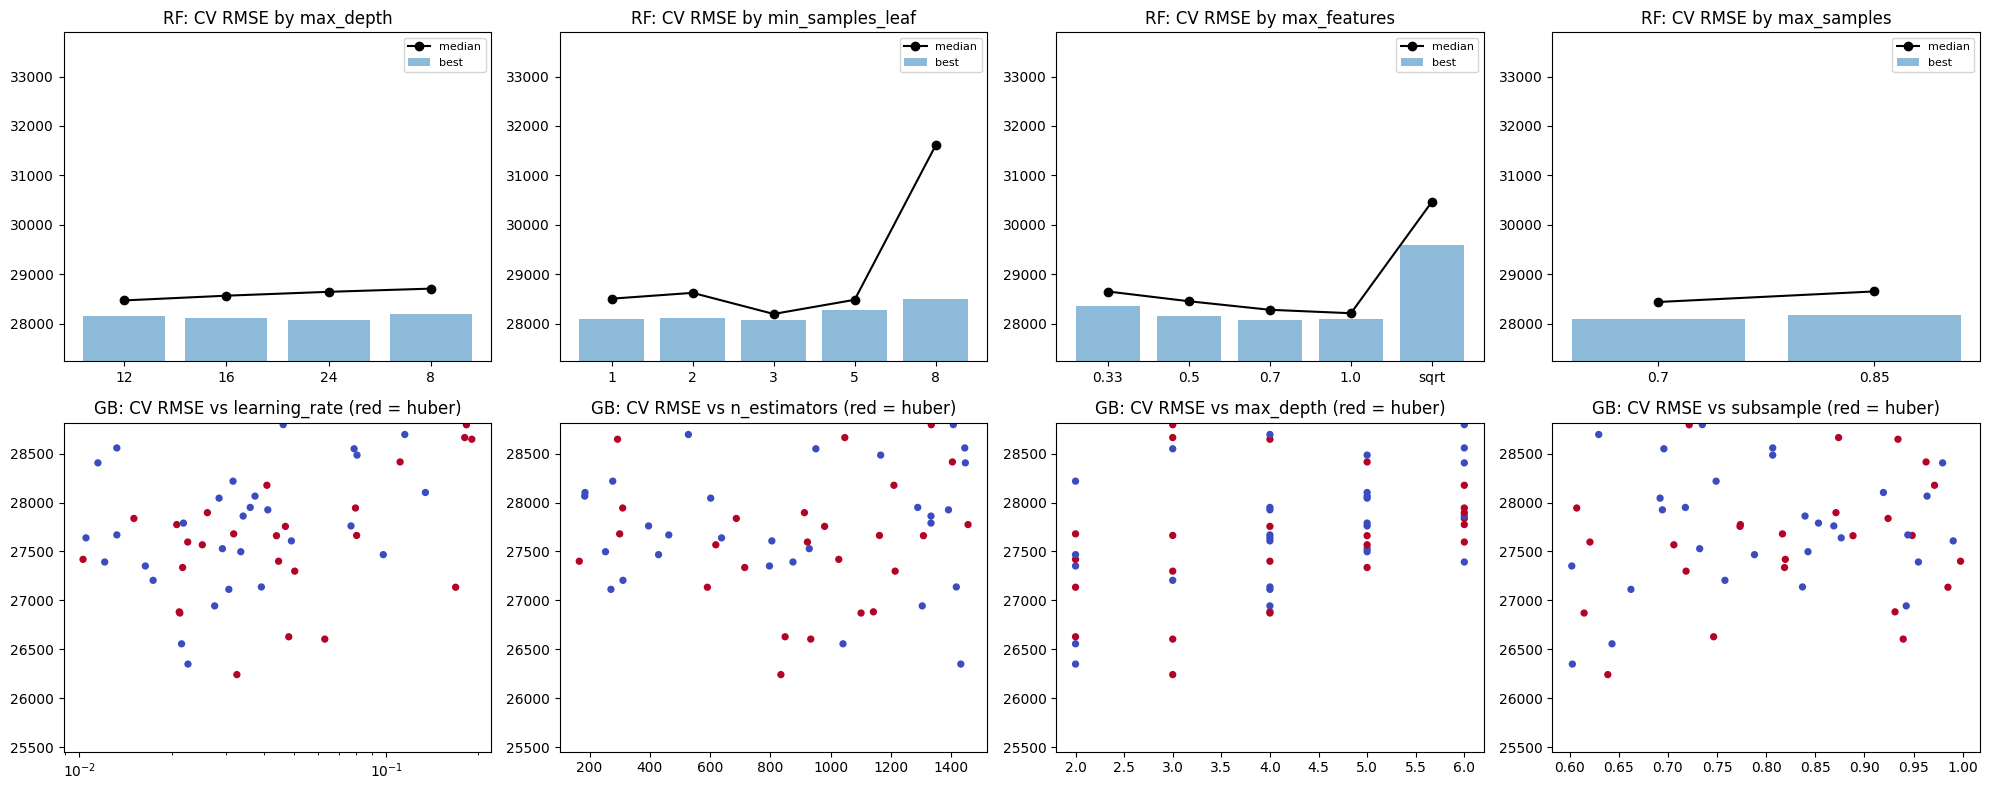

In [8]:
fig, ax = plt.subplots(2, 4, figsize=(20, 8))
for j, k in enumerate(["max_depth", "min_samples_leaf", "max_features", "max_samples"]):
    g = rf_table.assign(v=rf_table[k].astype(str)).groupby("v")["cv_rmse"]
    ax[0, j].bar(g.min().index, g.min().values, alpha=.5, label="best"); ax[0, j].plot(g.median().index, g.median().values, "ko-", label="median")
    ax[0, j].set_title(f"RF: CV RMSE by {k}"); ax[0, j].set_ylim(rf_table["cv_rmse"].min() * .97, rf_table["cv_rmse"].max() * 1.01)
    ax[0, j].legend(fontsize=8)
for j, k in enumerate(["learning_rate", "n_estimators", "max_depth", "subsample"]):
    ax[1, j].scatter(gb_table[k].astype(float), gb_table["cv_rmse"], c=gb_table["loss"].eq("huber"), cmap="coolwarm", s=18)
    ax[1, j].set_title(f"GB: CV RMSE vs {k} (red = huber)"); ax[1, j].set_ylim(gb_table["cv_rmse"].min() * .97, gb_table["cv_rmse"].quantile(.9))
    if k == "learning_rate": ax[1, j].set_xscale("log")
plt.tight_layout(); plt.show()

## 5. Tuned vs Phase-6 default: train / CV / validation (₹)

In [9]:
def evaluate(name, est):
    m = make_model(est)
    t0 = time.perf_counter(); m.fit(X_train, y_train); tt = time.perf_counter() - t0
    s = cross_validate(clone(m), X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    sr = cross_validate(clone(m), X_train, y_train, cv=rcv, scoring=SCORING, n_jobs=-1)   # unbiased by the search folds
    pt, pv = m.predict(X_train), m.predict(X_val)
    row = {"model": name, "Train RMSE": rmse(y_train, pt), "CV RMSE": -s["test_rmse"].mean(), "CV RMSE sd": s["test_rmse"].std(),
           "Rep-CV RMSE (5×3)": -sr["test_rmse"].mean(), "Rep-CV MAE (5×3)": -sr["test_mae"].mean(),
           "CV MAE": -s["test_mae"].mean(), "CV R²": s["test_r2"].mean(),
           "Val MAE": mean_absolute_error(y_val, pv), "Val MSE": mean_squared_error(y_val, pv), "Val RMSE": rmse(y_val, pv),
           "Val R²": r2_score(y_val, pv), "Val RMSLE": rmsle(y_val, pv), "Train time (s)": tt}
    if EVALUATE_TEST:
        ps = m.predict(X_test); row.update({"Test RMSE": rmse(y_test, ps), "Test MAE": mean_absolute_error(y_test, ps), "Test R²": r2_score(y_test, ps)})
    return row, m, pv

specs = {"Random Forest default": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
         "Random Forest tuned": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **RF_BEST),
         "Gradient Boosting default": GradientBoostingRegressor(random_state=RANDOM_STATE),
         "Gradient Boosting tuned": GradientBoostingRegressor(random_state=RANDOM_STATE, **GB_BEST)}
rows, fitted, val_pred = [], {}, {}
for n, e in specs.items():
    r, m, pv = evaluate(n, e); rows.append(r); fitted[n] = m; val_pred[n] = pv
summary = pd.DataFrame(rows).set_index("model")
summary["CV−Train gap"] = summary["CV RMSE"] - summary["Train RMSE"]
fmt = {c: "₹{:,.0f}" for c in ["Train RMSE", "CV RMSE", "CV RMSE sd", "Rep-CV RMSE (5×3)", "Rep-CV MAE (5×3)", "CV MAE",
                                 "Val MAE", "Val RMSE", "CV−Train gap"]}
fmt.update({"Val MSE": "{:.4g}", "CV R²": "{:.4f}", "Val R²": "{:.4f}", "Val RMSLE": "{:.4f}", "Train time (s)": "{:.2f}"})
display(summary.style.format(fmt))
print("Note: 'CV RMSE' uses the same 5 folds the search optimised on, so it is optimistic for the tuned models. "
      "'Rep-CV RMSE (5×3)' uses 15 different folds and is the fair default-vs-tuned comparison.")

,Train RMSE,CV RMSE,CV RMSE sd,Rep-CV RMSE (5×3),Rep-CV MAE (5×3),CV MAE,CV R²,Val MAE,Val MSE,Val RMSE,Val R²,Val RMSLE,Train time (s),CV−Train gap
model,,,,,,,,,,,,,,
Random Forest default,"₹13,425","₹28,906","₹5,696","₹29,368","₹10,082","₹9,984",0.7451,"₹11,708",2.062e+09,"₹45,407",0.6071,0.4238,0.16,"₹15,480"
Random Forest tuned,"₹21,990","₹28,095","₹6,252","₹28,427","₹9,895","₹9,809",0.7603,"₹11,543",2.005e+09,"₹44,780",0.6178,0.4187,0.44,"₹6,105"
Gradient Boosting default,"₹21,265","₹28,002","₹6,925","₹28,149","₹9,859","₹9,847",0.7610,"₹11,896",2.105e+09,"₹45,882",0.5988,0.4108,0.48,"₹6,736"
Gradient Boosting tuned,"₹21,647","₹26,242","₹7,258","₹27,086","₹9,593","₹9,493",0.7923,"₹11,693",1.994e+09,"₹44,657",0.6199,0.4066,2.57,"₹4,595"


Note: 'CV RMSE' uses the same 5 folds the search optimised on, so it is optimistic for the tuned models. 'Rep-CV RMSE (5×3)' uses 15 different folds and is the fair default-vs-tuned comparison.


In [10]:
# Validation diagnostics (comparison only): worst-row share and error by rent band
diag = []
for n, pv in val_pred.items():
    e = y_val.to_numpy() - pv; se = e ** 2; k = np.argmax(se)
    diag.append({"model": n, "Val RMSE": np.sqrt(se.mean()), "worst-row share of SSE": se[k] / se.sum(),
                 "Val RMSE w/o worst row": np.sqrt(np.delete(se, k).mean()), "Val median |%err|": np.median(np.abs(e) / y_val.to_numpy())})
display(pd.DataFrame(diag).set_index("model").round(3))
band = pd.qcut(y_val, 5, labels=["Q1 low", "Q2", "Q3", "Q4", "Q5 high"])
mae_band = pd.DataFrame({n: pd.Series(np.abs(y_val.to_numpy() - pv), index=y_val.index).groupby(band, observed=True).mean()
                         for n, pv in val_pred.items()}).round(0)
print("Validation MAE (₹) by rent quintile:"); display(mae_band)

,Val RMSE,worst-row share of SSE,Val RMSE w/o worst row,Val median |%err|
model,,,,
Random Forest default,45407.040,0.457,33489.714,0.221
Random Forest tuned,44780.465,0.437,33631.986,0.211
Gradient Boosting default,45881.912,0.441,34315.749,0.209
Gradient Boosting tuned,44656.835,0.404,34512.011,0.207


Validation MAE (₹) by rent quintile:


,Random Forest default,Random Forest tuned,Gradient Boosting default,Gradient Boosting tuned
Rent,,,,
Q1 low,2755.0,2769.0,2842.0,2668.0
Q2,2732.0,2602.0,2436.0,2321.0
Q3,4582.0,4408.0,3632.0,3814.0
Q4,7638.0,7148.0,7020.0,7085.0
Q5 high,42034.0,41974.0,44841.0,43837.0


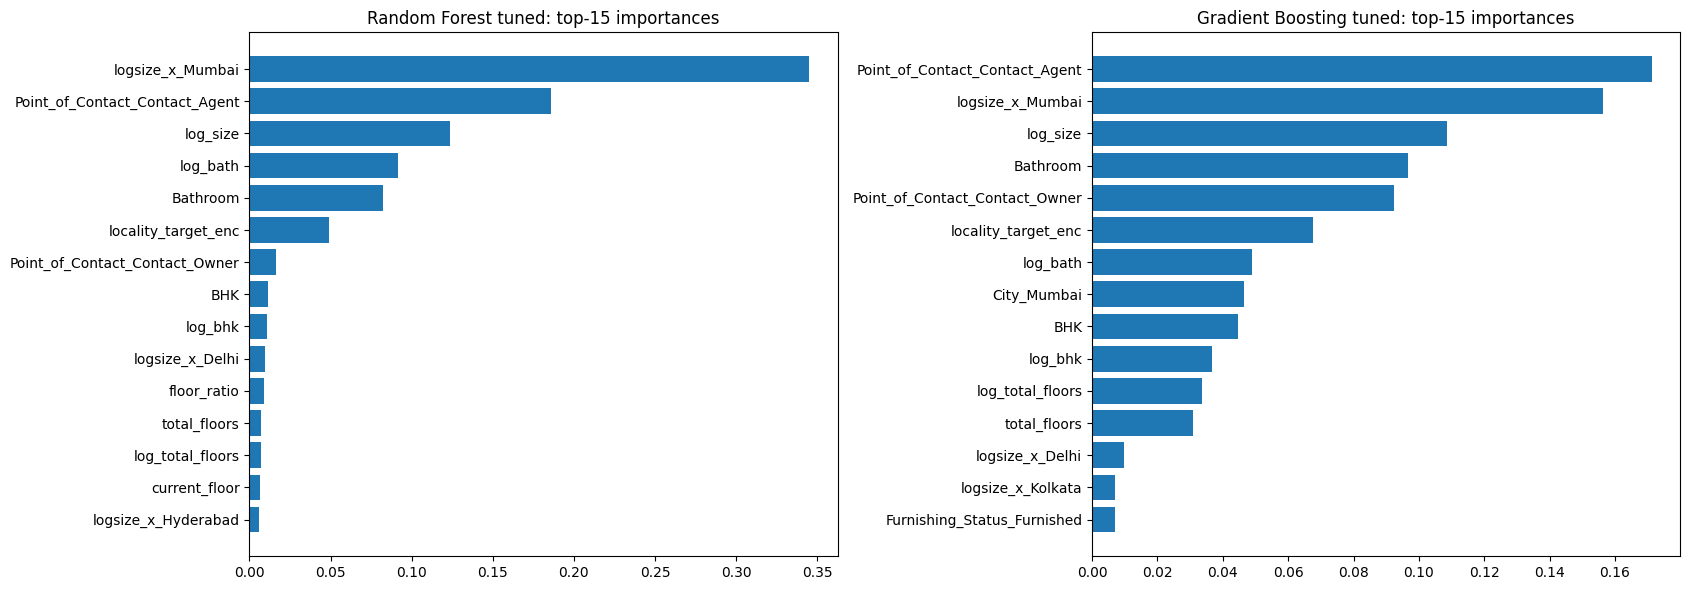

In [11]:
# Feature importances of the tuned models (impurity-based, from the fit on X_train)
fig, ax = plt.subplots(1, 2, figsize=(17, 6))
for a, n in zip(ax, ["Random Forest tuned", "Gradient Boosting tuned"]):
    imp = pd.Series(fitted[n].regressor_.named_steps["model"].feature_importances_, index=feature_names).sort_values()[-15:]
    a.barh(imp.index, imp.values); a.set_title(f"{n}: top-15 importances")
plt.tight_layout(); plt.show()

In [12]:
# Save outputs
summary.reset_index().to_csv("outputs/phase8_summary.csv", index=False)
rf_table.drop(columns="params").to_csv("outputs/phase8_search_random_forest.csv", index=False)
gb_table.drop(columns="params").to_csv("outputs/phase8_search_gradient_boosting.csv", index=False)
pd.concat({"random_forest": rf_top, "gradient_boosting": gb_top}).to_csv("outputs/phase8_top5_repeated_cv.csv")
for n in ["Random Forest tuned", "Gradient Boosting tuned"]:
    pv = val_pred[n]; key = n.replace(" tuned", "").lower().replace(" ", "_")
    pd.DataFrame({"row_id": X_val.index, "split": "val", "actual_rent": y_val.to_numpy(), "predicted_rent": pv,
                  "residual": y_val.to_numpy() - pv}).to_csv(f"outputs/predictions_phase8_{key}_tuned.csv", index=False)
to_py = lambda d: {k: (v.item() if hasattr(v, "item") else v) for k, v in d.items()}
best = {"random_forest": to_py(RF_BEST), "gradient_boosting": to_py(GB_BEST)}
with open("outputs/phase8_best_params.json", "w") as f:
    json.dump({"reference_id": EXPECTED_REFERENCE_ID,
               "selection": f"RandomizedSearchCV n_iter={N_ITER}, 5-fold CV RMSE (₹) on train; top-{TOP_K} re-scored on RepeatedKFold 5x3",
               **best}, f, indent=2)
print(json.dumps(best, indent=2))

{
  "random_forest": {
    "n_estimators": 300,
    "min_samples_split": 10,
    "min_samples_leaf": 1,
    "max_samples": 0.7,
    "max_features": 1.0,
    "max_depth": null
  },
  "gradient_boosting": {
    "learning_rate": 0.03262161345833058,
    "loss": "huber",
    "max_depth": 3,
    "max_features": 0.5,
    "min_samples_leaf": 8,
    "n_estimators": 835,
    "subsample": 0.6388705975083074
  }
}



## 6. Phase-8 decisions

### Chosen configurations (selected on train-only CV; validation not used to choose)
| Model | Tuned hyperparameters |
|---|---|
| **Gradient Boosting** | `loss="huber"`, `learning_rate=0.0326`, `n_estimators=835`, `max_depth=3`, `min_samples_leaf=8`, `subsample=0.639`, `max_features=0.5` |
| **Random Forest** | `n_estimators=300`, `max_depth=None`, `min_samples_split=10`, `min_samples_leaf=1`, `max_features=1.0`, `max_samples=0.7` |

### Default vs tuned (₹)
| Model | Train RMSE | **Rep-CV RMSE (5×3)** | Rep-CV MAE | CV−Train gap | Val MAE | Val RMSE | Val R² | Val RMSLE | Train time |
|---|---|---|---|---|---|---|---|---|---|
| RF default | 13,425 | 29,368 | 10,082 | 15,480 | 11,708 | 45,407 | 0.607 | 0.424 | 0.16 s |
| **RF tuned** | 21,990 | 28,427 (**−3.2%**) | 9,895 (−1.9%) | **6,105** | **11,543** | 44,780 | 0.618 | 0.419 | 0.44 s |
| GB default | 21,265 | 28,149 | 9,859 | 6,736 | 11,896 | 45,882 | 0.599 | 0.411 | 0.48 s |
| **GB tuned** | 21,647 | **27,086 (−3.8%)** | **9,593 (−2.7%)** | **4,595** | 11,693 | **44,657** | **0.620** | **0.407** | 2.6 s |

The standard 5-fold "CV RMSE" for the tuned models (RF ₹28,095, GB ₹26,242) reuses the folds the search optimised on, so it is **optimistic by about ₹300–850**. The fair comparison is the 15-fold repeated CV above. The standard CV figure is kept only for cross-phase comparability and flagged as such.

### Findings
1. **Tuning helps both ensembles, modestly and consistently.** On folds the search never saw, RMSE drops 3–4% and MAE 2–3%. Validation agrees in direction: RMSE, MAE, R² and RMSLE all improve for both models.
2. **The main effect is less overfitting.** RF's CV−train gap shrinks from ₹15.5k to ₹6.1k, because `min_samples_split=10` and 70% bootstrap samples stop the trees memorising rows. GB's gap shrinks from ₹6.7k to ₹4.6k (slower learning rate × more trees, 64% subsampling, feature subsampling).
3. **The Huber loss won for GB.** 7 of the top 10 GB configs use it. On the log target it down-weights the residual tail (the genuine luxury listings) instead of letting it steer the fit.
4. **Still within noise at the top.** The RF top-5 span only ₹200 on repeated CV and the GB top-5 span ₹520, against a fold sd of about ₹6.7–7k. Many nearby configurations are equivalent; the choice is robust rather than sharp.
5. **The high-rent tail is still where the error lives.** Validation MAE in the top rent quintile is ₹42–44k, against ₹2.3–7k in the other four. The ₹12,00,000 validation row still carries 40–44% of validation SSE. Without it, the tuned and default models are equal (₹33.5–34.5k), so most of the validation-RMSE gain sits on that one row and should not be over-read.
6. Hyperparameter sensitivity: RF prefers deep trees with leaf-level regularisation (`min_samples_split=10`) and row subsampling. GB prefers shallow trees (depth 2–3) with a small learning rate (0.02–0.035) and 800–1,400 trees.

### Decisions for Phase 9
* **Primary candidate: Gradient Boosting (tuned).** Best repeated-CV RMSE and MAE, best validation RMSE, R² and RMSLE, smallest overfitting gap.
* **Runner-up: Random Forest (tuned).** Best validation MAE (₹11,543), 6x faster to train.
* **Linear reference: Lasso (α=0.00251) and Ridge (α=15.85)** from Phase 7.
* Phase 9 will set `EVALUATE_TEST = True` once, for the full model set (the Phase-6 baselines plus the tuned models above), using `outputs/phase8_best_params.json` and `../phase7/outputs/phase7_best_params.json`.
* XGBoost / LightGBM / CatBoost are **not** in this search because they have not run yet (not installed locally; Colab results not reported). If they are run, they can be added to Phase 8 with the same protocol before Phase 9.
